## Preamble

In [10]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.0016; nt=2500

ntr=100

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

# def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
#     tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

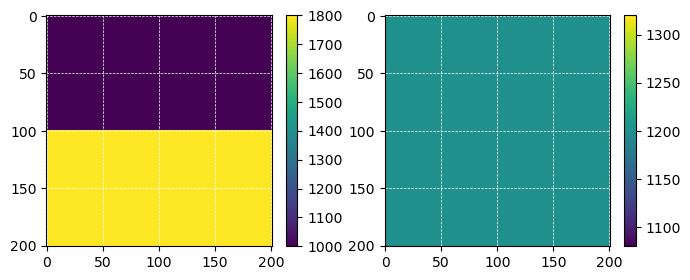

In [2]:
# True
!makevel nz=100 nx=$nx v000=1000 > c1
!makevel nz=101 nx=$nx v000=1800 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > true
!rm c1 c2 tmp

!makevel nz=1   nx=$nx v000=100  > topo

# Background
!makevel nz=$nz nx=$nx v000=1200 > init

#plot
plt.figure(figsize=(8,3))
true=read('true'); init=read('init')
plt.subplot(1,2,1); imshow(true)
plt.subplot(1,2,2); imshow(init)

In [3]:
!cat setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '10 10 1'
FILE_MODEL              true
MODEL_ATTRIBUTES        vp #'vp rho'
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '40 500 500'
FR                      '40 10  0'
DR                      '0  20 0'
NR                      100

SCOMP                   vz
RCOMP                   vz #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           2000
DT           0.002
FPEAK        7

## for PFEI ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
WEIGHTING           'none'

PARAMETER           'vp:1000:1800'

SMOOTHING     'none'
#PRECO         'z^0'


#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'


#SNAPSHOT     vz
#NSNAPSHOT    50

IF_USE_CHECKPOINT   F
RCOMP       px


In [4]:
vp=init
vs=vp/np.sqrt(3)
rho=1000.
def gvp(glda):     return  glda            *2*rho*vp
def gvs(glda,gmu): return (glda*(-2) + gmu)*2*rho*vs

## PSV2ndord

### uz-uz

#### Obs & Syn data

In [7]:
!cp setup_default setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 643320 Sep  9 15:30 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 5b7e433
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/09/2025
System time: 15:34:56
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.5*Vmax/dx
Requir

In [8]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 643320 Sep  9 15:30 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 5b7e433
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/09/2025
System time: 15:34:58
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.5*Vmax/dx
Requir

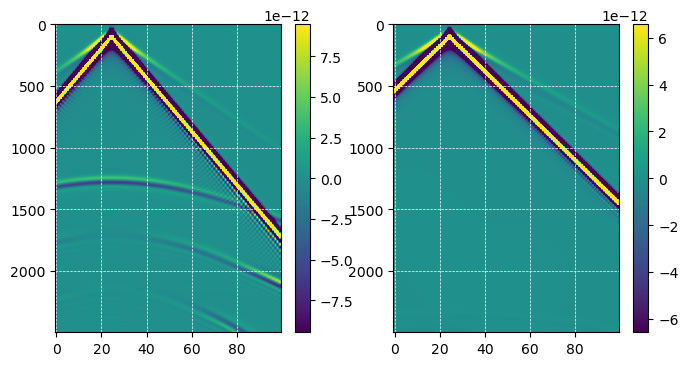

In [12]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=95)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=95)

#### Gradient

In [18]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux'" >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 46 Sep  9 18:41 ../../exe/GradientTest -> gradienttest_PSV2nd_FDSG_O4_velocities-density
 Git Commit: 3b2f322
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/09/2025
System time: 18:41:55
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coe

 it----        2000
 fld_a minmax values:  -3.16010297E-21   3.52535613E-21
 fld_u minmax values:  -1.58722601E-11   1.80332520E-11
 it----        1500
 fld_a minmax values:  -3.72541178E-20   8.79619017E-20
 fld_u minmax values:  -2.70666475E-11   3.79785196E-11
 it----        1000
 fld_a minmax values:  -1.64958633E-19   9.68156358E-20
 fld_u minmax values:  -2.73363103E-11   5.02843531E-11
 it----         500
 fld_a minmax values:  -3.32106683E-19   1.76495501E-19
 fld_u minmax values:  -6.20786964E-11   8.25637336E-11
 Elapsed time to evolve field           2.97880173E-03
 Elapsed time to load boundary          3.35707664E-02
 Elapsed time to update field           1.35314226    
 Elapsed time to rm source              4.72831726E-03
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       1.88307762E-02
 Elapsed time to update adj field            1.31200933    
 Elapsed time to evolve adj field            2.95972824E-03
 Elapsed time to extract fields   

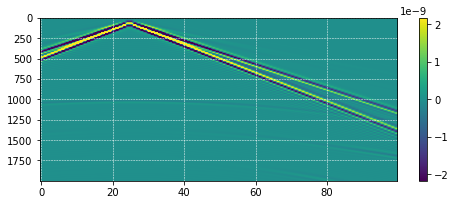

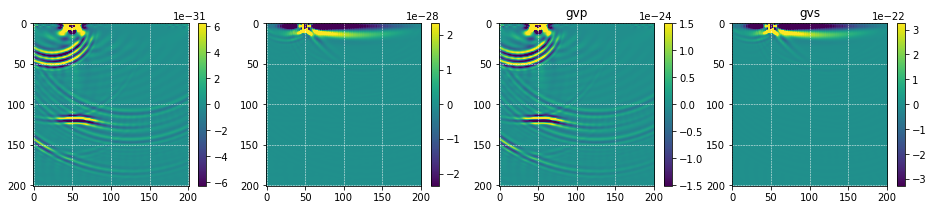

In [9]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest_PSV_FDSG_O4_velocities-density on gvp

In [10]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   1042.54858       1042.54846       12.2070312     -0.330939025      -2.71105245E-02 F
 1st cond   9.99999975E-05   1042.54834       1042.54846      -1.22070312     -0.330939025      0.271105260     T
 1st cond   1.00000005E-03   1042.54822       1042.54846     -0.244140610     -0.330939025       1.35552633     T
 1st cond   9.99999978E-03   1042.54553       1042.54846     -0.292968750     -0.330939025       1.12960517     T
 1st cond  0.100000001       1042.51477       1042.54846     -0.336914062     -0.330939025      0.982265413     T
 1st cond   1.00000000       1042.23022       1042.54846     -0.318237305     -0.330939025       1.03991270     T


In [11]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   1042.54846       1042.54846      -0.00000000     -0.330939025             Infinity T
 1st cond  -9.99999975E-05   1042.54846       1042.54846      -0.00000000     -0.330939025             Infinity T
 1st cond  -1.00000005E-03   1042.54858       1042.54846     -0.122070305     -0.330939025       2.71105266     F
 1st cond  -9.99999978E-03   1042.55164       1042.54846     -0.317382812     -0.330939025       1.04271245     F
 1st cond -0.100000001       1042.57690       1042.54846     -0.284423828     -0.330939025       1.16354179     F
 1st cond  -1.00000000       1042.87866       1042.54846     -0.330200195     -0.330939025       1.00223756     F


#### gradienttest_PSV_FDSG_O4_velocities-density on gvs

In [12]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   71.3662491       71.3663330      -8.39233398      -5.38862038      0.642088413     T
 1st cond   9.99999975E-05   71.3656998       71.3663330      -6.33239746      -5.38862038      0.850960553     T
 1st cond   1.00000005E-03   71.3598480       71.3663330      -6.48498487      -5.38862038      0.830937982     T
 1st cond   9.99999978E-03   71.3039474       71.3663330      -6.23855591      -5.38862038      0.863760829     T
 1st cond  0.100000001       70.7562332       71.3663330      -6.10099792      -5.38862038      0.883235872     T
 1st cond   1.00000000       66.9689026       71.3663330      -4.39743042      -5.38862038       1.22540212     T


In [13]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   71.3663559       71.3663330      -2.28881836      -5.38862038       2.35432410     F
 1st cond  -9.99999975E-05   71.3669205       71.3663330      -5.87463379      -5.38862038      0.917269170     F
 1st cond  -1.00000005E-03   71.3723984       71.3663330      -6.06536818      -5.38862038      0.888424277     F
 1st cond  -9.99999978E-03   71.4283142       71.3663330      -6.19812012      -5.38862038      0.869395912     F
 1st cond -0.100000001       71.9962540       71.3663330      -6.29920959      -5.38862038      0.855443895     F
 1st cond  -1.00000000       77.1340637       71.3663330      -5.76773071      -5.38862038      0.934270442     F


### vz-vx

#### Obs & Syn data

In [14]:
!cp setup_default setup
!echo "SCOMP       vz" >> setup
!echo "RCOMP       vx" >> setup
!echo "DIR_OUT     results_obs" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 630664 Nov 20 15:14 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 65073d2
 Git Branch: DAS
 Compiler: gfortran v11.4.0
 Version: 11.4.0
 Endianness:         1234
 System date: 11/20/2023
System time: 16:31:37
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606 *Vmax/dx

In [15]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "SCOMP       vz" >> setup
!echo "RCOMP       vx" >> setup
!echo "DIR_OUT     results_syn" >> setup
run(app='../../exe/fwd_PSV_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 630664 Nov 20 15:14 ../../exe/fwd_PSV_FDSG_O4_
 Git Commit: 65073d2
 Git Branch: DAS
 Compiler: gfortran v11.4.0
 Version: 11.4.0
 Endianness:         1234
 System date: 11/20/2023
System time: 16:31:39
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.606 *Vmax/dx

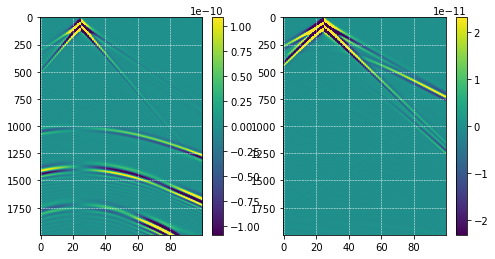

In [16]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [17]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "SCOMP       vz" >> setup
!echo "RCOMP       vx" >> setup
!echo "ALPHAS      1 " >> setup
run(app='../../exe/gradienttest_PSV_FDSG_O4_velocities-density')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 43 Nov 20 16:05 ../../exe/GradientTest -> gradienttest_PSV_FDSG_O4_velocities-density
 Git Commit: 65073d2
 Git Branch: DAS
 Compiler: gfortran v11.4.0
 Version: 11.4.0
 Endianness:         1234
 System date: 11/20/2023
System time: 16:31:48
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D P-SV (ELastic) propagation
1st-order Velocity-Stress formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ

 it----         500
 fld_a minmax values:  -4.16835915E-18   4.38408909E-18
 fld_u minmax values:  -2.44740228E-09   2.71616063E-09
 Elapsed time to load boundary               1.96070671E-02
 Elapsed time to update stresses            0.489306450    
 Elapsed time to rm source stresses          6.92844391E-04
 Elapsed time to update velocities          0.400392532    
 Elapsed time to rm source velocities        6.88552856E-04
 Elapsed time ----------------------------
 Elapsed time to add adjsource stresses      9.45353508E-03
 Elapsed time to update adj stresses        0.492679596    
 Elapsed time to add adjsource velocities    7.98106194E-03
 Elapsed time to update adj velocities      0.450386763    
 Elapsed time to extract&write fields        0.00000000    
 Elapsed time to correlate                   2.66001225E-02
 Viewing the snapshots (if written) with SU ximage/xmovie:
 ximage < snap_rfield%*  n1=249 perc=99
 xmovie < snap_rfield%*  n1=249 n2=249 clip=?e-?? loop=2 title=%g


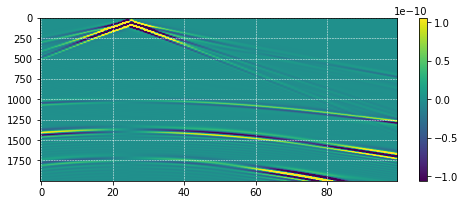

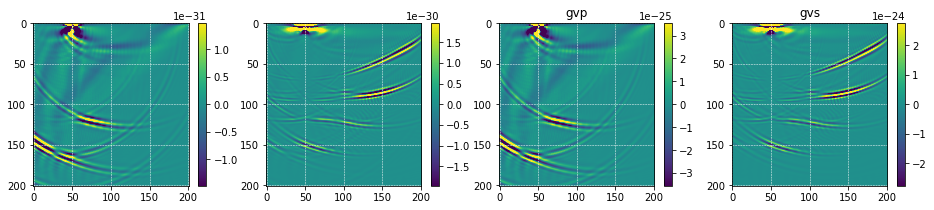

In [18]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest_PSV_FDSG_O4_velocities-density on gvp

In [19]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "SCOMP       vz" >> setup
!echo "RCOMP       vx" >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   16.4475327       16.4475422     -0.953674316     -0.485732079      0.509326994     T
 1st cond   9.99999975E-05   16.4474888       16.4475422     -0.534057617     -0.485732079      0.909512520     T
 1st cond   1.00000005E-03   16.4471321       16.4475422     -0.410079926     -0.485732079       1.18448150     T
 1st cond   9.99999978E-03   16.4428616       16.4475422     -0.468063354     -0.485732079       1.03774858     T
 1st cond  0.100000001       16.4012318       16.4475422     -0.463104248     -0.485732079       1.04886115     T
 1st cond   1.00000000       16.0232410       16.4475422     -0.424301147     -0.485732079       1.14478147     T


In [20]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo "SCOMP       vz" >> setup
!echo "RCOMP       vx" >> setup
#!echo "PARAMETER   'vp:1500:2000'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   16.4475403       16.4475422      0.190734863     -0.485732079      -2.54663491     T
 1st cond  -9.99999975E-05   16.4475899       16.4475422     -0.476837158     -0.485732079       1.01865399     F
 1st cond  -1.00000005E-03   16.4480171       16.4475422     -0.474929780     -0.485732079       1.02274501     F
 1st cond  -9.99999978E-03   16.4520760       16.4475422     -0.453376770     -0.485732079       1.07136512     F
 1st cond -0.100000001       16.4935360       16.4475422     -0.459938049     -0.485732079       1.05608153     F
 1st cond  -1.00000000       16.9424934       16.4475422     -0.494951248     -0.485732079      0.981373608     F


#### gradienttest_PSV_FDSG_O4_velocities-density on gvs

In [21]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "SCOMP        vz" >> setup
!echo "RCOMP        vx" >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup
!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   8.18423367       8.18424988      -1.62124634      -1.33596861      0.824038029     T
 1st cond   9.99999975E-05   8.18412209       8.18424988      -1.27792358      -1.33596861       1.04542136     T
 1st cond   1.00000005E-03   8.18292904       8.18424988      -1.32083881      -1.33596861       1.01145470     T
 1st cond   9.99999978E-03   8.17117214       8.18424988      -1.30777359      -1.33596861       1.02155960     T
 1st cond  0.100000001       8.05730343       8.18424988      -1.26946449      -1.33596861       1.05238760     T
 1st cond   1.00000000       7.30140877       8.18424988     -0.882841110      -1.33596861       1.51326048     T


In [22]:
!cp setup_default setup
!echo 'FILE_MODEL   init' >> setup
!echo "SCOMP        vz" >> setup
!echo "RCOMP        vx" >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
!../../exe/gradienttest_PSV_FDSG_O4_velocities-density  setup > out

!echo '            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha    pert%f    curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   8.18426991       8.18424988      -2.00271606      -1.33596861      0.667078376     F
 1st cond  -9.99999975E-05   8.18439388       8.18424988      -1.44004822      -1.33596861      0.927724898     F
 1st cond  -1.00000005E-03   8.18554211       8.18424988      -1.29222858      -1.33596861       1.03384852     F
 1st cond  -9.99999978E-03   8.19740772       8.18424988      -1.31578445      -1.33596861       1.01533997     F
 1st cond -0.100000001       8.31975937       8.18424988      -1.35509491      -1.33596861      0.985885620     F
 1st cond  -1.00000000       9.90973282       8.18424988      -1.72548294      -1.33596861      0.774257779     F
